In [ ]:
import transformers
import torch
import sys

print("Python:", sys.version)
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Transformers: 5.16.1
PyTorch: 2.11.0+cu128


In [ ]:
!pip install -q --no-deps \
    transformers==4.46.3 \
    tokenizers==0.20.3 \
    huggingface-hub==0.36.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.1 MB/s eta 0:00:00


restart environment, if run in colab

In [ ]:
!git clone https://github.com/upunaprosk/hate-prototypes.git
%cd hate-prototypes

Cloning into 'hate-prototypes'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 106 (delta 54), reused 69 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 8.90 MiB | 25.24 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/hate-prototypes


The notebook for convenience is split in 6 sections:
1. **Data preparation**
2. **Model fine-tuning**
3. **Early exiting evaluation (entropy=DeeBERT)**
4. **Results Analysis (entropy=DeeBERT)**
5. **Early exiting evaluation (patience=Pabee)**
6. **Results Analysis (patience=Pabee)**

# 1. **Prepare data**

Create CSV files for the training and test splits.

**Each file must contain a `sentence` column with the input text and a `label` column with binary labels, where `0` denotes non-hateful content and `1` denotes hateful content.**

The data directory should contain files named `<dataset>_train.csv` and `<dataset>_test.csv`, using the same dataset prefix for both splits. For example, for the `hatexplain` dataset, the expected files are `hatexplain_train.csv` and `hatexplain_test.csv`.


In [ ]:
!unzip all_data_hate.zip -d 'data'
!ls data

Archive:  all_data_hate.zip
  inflating: data/hatexplain_test.csv  
  inflating: data/hatexplain_train.csv  
  inflating: data/hatexplain_valid.csv  
  inflating: data/ihc_test.csv       
  inflating: data/ihc_train.csv      
  inflating: data/ihc_valid.csv      
  inflating: data/olid_test.csv      
  inflating: data/olid_train.csv     
  inflating: data/sbic_test.csv      
  inflating: data/sbic_train.csv     
  inflating: data/sbic_valid.csv     
hatexplain_test.csv   ihc_test.csv   olid_test.csv   sbic_train.csv
hatexplain_train.csv  ihc_train.csv  olid_train.csv  sbic_valid.csv
hatexplain_valid.csv  ihc_valid.csv  sbic_test.csv


label
0    11405
1    24019
Name: count, dtype: int64


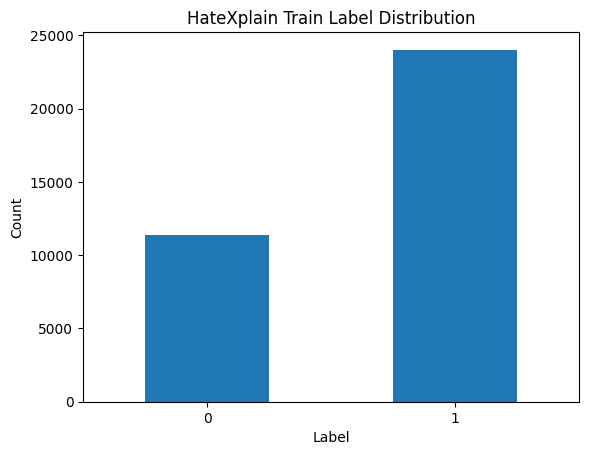

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/sbic_train.csv")

print(df["label"].value_counts().sort_index())

df["label"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Label")
plt.ylabel("Count")
plt.title("HateXplain Train Label Distribution")
plt.xticks(rotation=0)
plt.show()

# 2. **Model Training**

The same trained model is used for both the **entropy-based** and **patience-based** early-exit evaluations. The two approaches therefore share the same fine-tuning procedure and intermediate classifiers; they differ only in the criterion used to decide when to exit during inference.

The BERT architecture is extended with an intermediate classification head, or highway classifier, after each Transformer layer. Training follows the DeeBERT procedure in two stages. First, the base BERT model and final classifier are fine-tuned on the training data. In the second stage, the base model parameters are kept fixed while the intermediate highway classifiers are trained.

After training, the resulting checkpoint is reused for both early-exit methods:

* **Entropy-based exiting** stops when the entropy of an intermediate prediction falls below a chosen threshold.
* **Patience-based exiting** stops when the prediction remains unchanged across a chosen number of consecutive layers.

This allows the two exit criteria to be compared using the same underlying model and intermediate classifiers.

Training arguments:

* `--model_type "bert"` – specifies the BERT architecture.
* `--model_name_or_path "bert-base-cased"` – initializes the model from the pretrained BERT checkpoint from Hugging Face.
* `--task_name "hatexplain"` – specifies the dataset/task.
* `--do_train` – enables model training.
* `--data_dir "./data/"` – directory containing the training and test CSV files. The script expects files named `<task_name>_train.csv` and `<task_name>_test.csv`.
* `--max_seq_length 256` – maximum input sequence length.
* `--per_gpu_train_batch_size 8` – training batch size per GPU.
* `--gradient_accumulation_steps 8` – accumulates gradients across multiple batches before updating the model parameters.
* `--learning_rate 1e-5` – learning rate used for fine-tuning.
* `--num_train_epochs 3` – number of training epochs.
* `--seed 0` – random seed used for the run.
* `--output_dir "./deebert-s0-hatexplain/"` – directory where the trained model is stored.


In [ ]:
%cd ..
%cd hate-prototypes

/content
/content/hate-prototypes


In [ ]:
# to pad to the max lengths, first compute the max lenght
import pandas as pd
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

for split in ["train", "test"]:
    df = pd.read_csv(f"./data/hatexplain_{split}.csv")

    lengths = df["sentence"].astype(str).apply(
        lambda x: len(tokenizer(x, truncation=False)["input_ids"])
    )

    print(
        split,
        "| mean:", round(lengths.mean(), 1),
        "| 95%:", int(lengths.quantile(0.95)),
        "| 99%:", int(lengths.quantile(0.99)),
        "| max:", lengths.max()
    )

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

train | mean: 32.2 | 95%: 64 | 99%: 74 | max: 125
test | mean: 31.9 | 95%: 64 | 99%: 73 | max: 102


In [ ]:
!python deebert/deebert_finetune.py \
    --model_type bert \
    --model_name_or_path bert-base-cased \
    --task_name hatexplain \
    --do_train \
    --data_dir ./data/ \
    --max_seq_length 128 \
    --per_gpu_train_batch_size 8 \
    --gradient_accumulation_steps 8 \
    --per_gpu_eval_batch_size 1 \
    --learning_rate 1e-5 \
    --num_train_epochs 1 \
    --seed 0 \
    --output_dir ./deebert-s0-hatexplain/ \
    --plot_data_dir ./plotting/ \
    --save_steps 0 \
    --overwrite_output_dir \
    --eval_after_first_stage

2026-09-08 22:54:49.303468: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-08 22:54:49.373925: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
model.safetensors: 100% 436M/436M [00:01<00:00, 235MB/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['bert.encoder.highway.0.classifier.bias', 'bert.encoder.highway.0.classifier.weight', 'bert.encoder.highway.0.pooler.dense.bias', 'bert.encoder.highway.0.pooler.dense.weight', '

# DeeBERT Entropy Baselines

DeeBERT is an early-exiting technique introduced by Xin et al. (2020) to accelerate BERT inference by allowing samples to exit at intermediate Transformer layers when the model is sufficiently confident.

Confidence is measured using the entropy of the predicted class distribution at layer \(i\):

$$
H(\mathbf{p}_i) = -\sum_{c=1}^{C} p_{i,c}\log p_{i,c}
$$

The model exits at the first layer for which:

$$
H(\mathbf{p}_i) < \tau
$$

where \(\tau\) is the entropy threshold. Different threshold values produce different trade-offs between predictive performance and computational efficiency.

The implementation is based on the official DeeBERT code, with updated imports for compatibility with newer versions of the Hugging Face Transformers library.


## 3. Early exiting (Entropy)

The trained model is evaluated using entropy-based early exiting.
**At each Transformer layer, the entropy of the intermediate classifier is compared with a predefined threshold. If the entropy falls below this threshold, the model stops and returns the prediction from that layer.**

Lower entropy thresholds require the intermediate classifier to be more confident before exiting, which generally results in later exits. Higher thresholds allow the model to exit earlier.

**For the binary classification task, the maximum possible entropy is approximately 0.693 (\(\ln 2\)).**
Therefore, thresholds close to this value represent more aggressive early exiting. A threshold of 0 disables early exiting, since entropy cannot be lower than zero.

The model is evaluated separately for each entropy threshold:

```
sdir = "./deebert-s0-hatexplain/"

for entropy in ENTROPIES:

    !python deebert/deebert_finetune.py \
        --model_type "bert" \
        --model_name_or_path "$sdir" \
        --task_name "hatexplain" \
        --do_eval \
        --data_dir "./data/" \
        --output_dir "$sdir" \
        --max_seq_length 256 \
        --early_exit_entropy {entropy} \
        --per_gpu_eval_batch_size 1 \
        --eval_highway
```

Here, `--early_exit_entropy` specifies the entropy threshold used for the exit decision. `--per_gpu_eval_batch_size 1` evaluates one example at a time so that each example can have its own exit layer, and `--eval_highway` enables evaluation of the intermediate classifiers used for early exiting.

Different entropy thresholds are evaluated to measure how predictive performance changes as the model exits at different depths.


In [ ]:
import numpy as np

deeopt_entropies = (
    [round(x, 3) for x in np.arange(0.61, 0.701, 0.005)] + # 0.61 → 0.70
    [0, 0.1, 0.2, 0.3, 0.4, 0.5]
)
ENTROPIES = deeopt_entropies[:5] # drop for test

sdir = "./deebert-s0-hatexplain/"

for entropy in ENTROPIES:

    !python deebert/deebert_finetune.py \
        --model_type "bert" \
        --model_name_or_path "$sdir" \
        --task_name "hatexplain" \
        --do_eval \
        --data_dir "./data/" \
        --output_dir "$sdir" \
        --max_seq_length 256 \
        --early_exit_entropy {entropy} \
        --per_gpu_eval_batch_size 1 \
        --eval_highway

2026-09-08 22:58:27.967516: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-08 22:58:28.039104: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
0.61
0.61
Evaluating: 100% 1924/1924 [00:22<00:00, 84.89it/s]
Eval time: 22.66554307937622
{'accuracy': 0.7198544698544699, 'f1_binary': 0.7514983863531581, 'f1_macro': 0.7152369835279787, 'pr_auc': np.float64(0.838596090117405)}
Exit layer counter {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 179, 7: 171, 8: 66, 9: 365, 10: 269, 11: 32, 12: 842}
Expected saving 0.8329002079002079
Av

In [ ]:
!ls $sdir

config.json			  entropy_0.63_eval_results.txt
entropy_0.615_eval_results.txt	  entropy_0.63_individual.parquet
entropy_0.615_individual.parquet  eval_results.txt
entropy_0.61_eval_results.txt	  model.safetensors
entropy_0.61_individual.parquet   special_tokens_map.json
entropy_0.625_eval_results.txt	  tokenizer_config.json
entropy_0.625_individual.parquet  training_args.bin
entropy_0.62_eval_results.txt	  vocab.txt
entropy_0.62_individual.parquet


## 4. Results analysis (Entropy)

For each threshold, the macro F1 score and average exit layer are extracted from the corresponding result file.

The average exit layer indicates how much of the 12-layer BERT model is used before making a prediction. A lower average exit layer corresponds to earlier exiting and lower computational cost.

A simple layer-based speedup is estimated as:

$$
\text{speedup} = \frac{12}{\text{average exit layer}}
$$

where 12 is the total number of Transformer layers. For example, an average exit layer of 6 corresponds to an estimated speedup of \(12/6 = 2\).


In [ ]:
import os
import pandas as pd

model_dir = "./deebert-s0-hatexplain/"

NUM_LAYERS = 12

rows = []

for entropy in ENTROPIES:
    entropy_value = float(entropy)

    file_path = os.path.join(
        model_dir,
        f"entropy_{entropy_value}_eval_results.txt"
    )

    if not os.path.exists(file_path):
        print(f"Missing: {file_path}")
        continue

    result = {}

    with open(file_path, "r") as f:
        for line in f:
            if " = " in line:
                key, value = line.strip().split(" = ", 1)

                try:
                    result[key] = float(value)
                except ValueError:
                    result[key] = value

    avg_exit = result["avg_exit_layer"]

    rows.append({
        "entropy": entropy_value,
        "f1_macro": result["f1_macro"],
        "avg_exit_layer": avg_exit,
        "speedup": NUM_LAYERS / avg_exit
    })

df = pd.DataFrame(rows)
df = df.sort_values("entropy").reset_index(drop=True)

print(
    df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

 entropy  f1_macro  avg_exit_layer  speedup
  0.6100    0.7152          9.9948   1.2006
  0.6150    0.7161          9.8170   1.2224
  0.6200    0.7199          9.6492   1.2436
  0.6250    0.7232          9.4621   1.2682
  0.6300    0.7240          9.2490   1.2974


In [ ]:
!ls deebert-s0-hatexplain

config.json			  entropy_0.63_eval_results.txt
entropy_0.615_eval_results.txt	  entropy_0.63_individual.parquet
entropy_0.615_individual.parquet  eval_results.txt
entropy_0.61_eval_results.txt	  model.safetensors
entropy_0.61_individual.parquet   special_tokens_map.json
entropy_0.625_eval_results.txt	  tokenizer_config.json
entropy_0.625_individual.parquet  training_args.bin
entropy_0.62_eval_results.txt	  vocab.txt
entropy_0.62_individual.parquet


Individual predictions:

In [ ]:
import pandas as pd

data = pd.read_csv("./data/hatexplain_test.csv")

entropy = 0.625

preds = pd.read_parquet(
    f"./deebert-s0-hatexplain/entropy_{entropy}_individual.parquet"
)

preds.head(20)

,criterion,value,example_id,true_label,prediction,exit_layer,saving
0,entropy,0.625,0,0,0,9,0.250000
1,entropy,0.625,1,0,0,12,0.000000
2,entropy,0.625,2,1,0,12,0.000000
3,entropy,0.625,3,1,0,12,0.000000
4,entropy,0.625,4,1,0,10,0.166667
5,entropy,0.625,5,1,1,4,0.666667
6,entropy,0.625,6,1,0,12,0.000000
7,entropy,0.625,7,1,0,12,0.000000
8,entropy,0.625,8,1,0,12,0.000000
9,entropy,0.625,9,0,0,12,0.000000


# PABEE Patience Baselines

PABEE (Zhou et al., 2020) is an early-exiting technique that allows inference to stop when the predictions of consecutive Transformer layers become sufficiently stable.

At layer \(i\), the predicted class is:

$$
\hat{y}_i = \arg\max_c p_{i,c}
$$

where \(p_{i,c}\) is the predicted probability of class \(c\) at layer \(i\).

Instead of using prediction confidence, as in the DeeBERT entropy baseline, the patience-based criterion checks whether consecutive intermediate classifiers produce the same predicted class. The model exits once the prediction remains unchanged for a specified number of consecutive layers determined by the patience parameter \(t\).

Larger patience values require predictions to remain stable across more layers and therefore generally result in later exits, while smaller patience values allow earlier exits.

In this implementation, the same DeeBERT-trained model and intermediate classifiers are used for both entropy-based and patience-based early exiting. The difference between the two baselines is therefore the inference-time exit criterion: DeeBERT uses an entropy threshold, while the PABEE-style baseline uses prediction consistency across consecutive layers.

Different patience values are evaluated to study the trade-off between predictive performance and computational cost.

A patience value of 1 = the model may exit once two consecutive layers make the same prediction.

As the patience value increases, more consecutive agreements are required, so the model tends to exit at later layers and use more computation.

For a 12-layer BERT model, a patience value of 12 = full-depth inference.


## 5. Early exiting (Patience)

For patience-based early exiting, the model exits when the prediction remains unchanged across several consecutive Transformer layers. The number of consecutive agreements required before exiting is controlled by the patience value.

Smaller patience values allow for earlier exit, while larger values require the prediction to remain stable across more layers.

Arguments:

* `--use_pabee` enables patience-based early exiting.
* `--patience` sets the patience value.
* `--per_gpu_eval_batch_size 1` evaluates one example at a time and allows the exit layer to be recorded for each example.
* `--eval_highway` evaluates the intermediate classifiers used for early exiting.

```python
PATIENCES = [2, 3, 4, 5, 6, 8, 10, 12]

sdir = "./deebert-s0-hatexplain/"

for patience in PATIENCES:

    !python deebert/deebert_finetune.py \
        --model_type "bert" \
        --model_name_or_path "$sdir" \
        --task_name "hatexplain" \
        --do_eval \
        --data_dir "./data/" \
        --output_dir "$sdir" \
        --max_seq_length 256 \
        --per_gpu_eval_batch_size 1 \
        --use_pabee \
        --patience {patience} \
        --eval_highway
```

Different patience values are evaluated to study the trade-off between predictive performance and computational cost.


In [12]:
# Patience values to evaluate
PATIENCES = [2, 3, 4, 5, 6, 8, 10, 12]

# Directory containing the trained DeeBERT model
sdir = "./deebert-s0-hatexplain/"

for patience in PATIENCES:

    print(f"\n===== Patience: {patience} =====\n")

    !python deebert/deebert_finetune.py \
        --model_type "bert" \
        --model_name_or_path "$sdir" \
        --task_name "hatexplain" \
        --do_eval \
        --data_dir "./data/" \
        --output_dir "$sdir" \
        --max_seq_length 128 \
        --per_gpu_eval_batch_size 1 \
        --use_pabee \
        --patience {patience} \
        --eval_highway


===== Patience: 2 =====

2026-09-08 23:01:18.822272: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-08 23:01:18.893134: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
-1
-1
Evaluating: 100% 1924/1924 [00:09<00:00, 196.42it/s]
Eval time: 9.796267986297607
{'accuracy': 0.5935550935550935, 'f1_binary': 0.7449445531637312, 'f1_macro': 0.3724722765818656, 'pr_auc': np.float64(0.7967775467775468)}
Exit layer counter {1: 0, 2: 0, 3: 1924, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0}
Expected saving 0.25
A

## 6. Results analysis (Patience)

The metrics are same as for the entropy results analysis.

In [15]:
import os
import pandas as pd

model_dir = "./deebert-s0-hatexplain/"

NUM_LAYERS = 12

rows = []

for patience in PATIENCES:

    file_path = os.path.join(
        model_dir,
        f"patience_{patience}_eval_results.txt"
    )

    if not os.path.exists(file_path):
        print(f"Missing: {file_path}")
        continue

    result = {}

    with open(file_path, "r") as f:
        for line in f:
            if " = " in line:
                key, value = line.strip().split(" = ", 1)

                try:
                    result[key] = float(value)
                except ValueError:
                    result[key] = value

    avg_exit = result["avg_exit_layer"]

    rows.append({
        "patience": patience,
        "f1_macro": result["f1_macro"],
        "avg_exit_layer": avg_exit,
        "speedup": NUM_LAYERS / avg_exit
    })

df_pabee = pd.DataFrame(rows)
df_pabee = df_pabee.sort_values("patience").reset_index(drop=True)

print(
    df_pabee.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

 patience  f1_macro  avg_exit_layer  speedup
        2    0.3725          3.0000   4.0000
        3    0.3725          4.0000   3.0000
        4    0.3725          5.0000   2.4000
        5    0.4790          6.2989   1.9051
        6    0.5576          7.5587   1.5876
        8    0.6388          9.5941   1.2508
       10    0.6863         11.2827   1.0636
       12    0.7332         12.0000   1.0000


Individual predictions

In [14]:
import pandas as pd

data = pd.read_csv("./data/hatexplain_test.csv")

patience = 5

preds = pd.read_parquet(
    f"./deebert-s0-hatexplain/patience_{patience}_individual.parquet"
)

preds.head(20)

,criterion,value,example_id,true_label,prediction,exit_layer,saving
0,patience,5,0,0,0,11,0.083333
1,patience,5,1,0,1,6,0.500000
2,patience,5,2,1,1,6,0.500000
3,patience,5,3,1,1,6,0.500000
4,patience,5,4,1,0,11,0.083333
5,patience,5,5,1,1,6,0.500000
6,patience,5,6,1,1,6,0.500000
7,patience,5,7,1,1,6,0.500000
8,patience,5,8,1,1,6,0.500000
9,patience,5,9,0,1,6,0.500000
